# Example 4: 
## PyPSA v.s PSS/E
This notebook demonstrates how to compare the PyPSA and PSS/E results.

pre compiled PSS/E data can be found in the database with the specifics found here.

if you can and have the license, feel free to run the PSSE simulation yourself 


This example uses the RTS GMLC case system with wave energy converter farm. (74 buses)

In [1]:
import wecgrid

example4 = wecgrid.Engine()
example4.case("./grid_models/RTS-96.RAW")
example4.load(["pypsa"])
example4.load(["pypsa", "psse"]) # Uncomment to load PSS/E

C:\Users\alexb\research\WEC-Grid\src\wecgrid\modelers\power_system\base.py:1021: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  tdf[col] = pd.NA


Powerflow solution failed.


SLD Data Summary:
  Buses: 73
  Lines: 110
  Generators: 33
  Loads: 51


(<Figure size 1400x1000 with 1 Axes>,
 <AxesSubplot:title={'center':'Single-Line Diagram - RTS 96 (PYPSA)'}>)

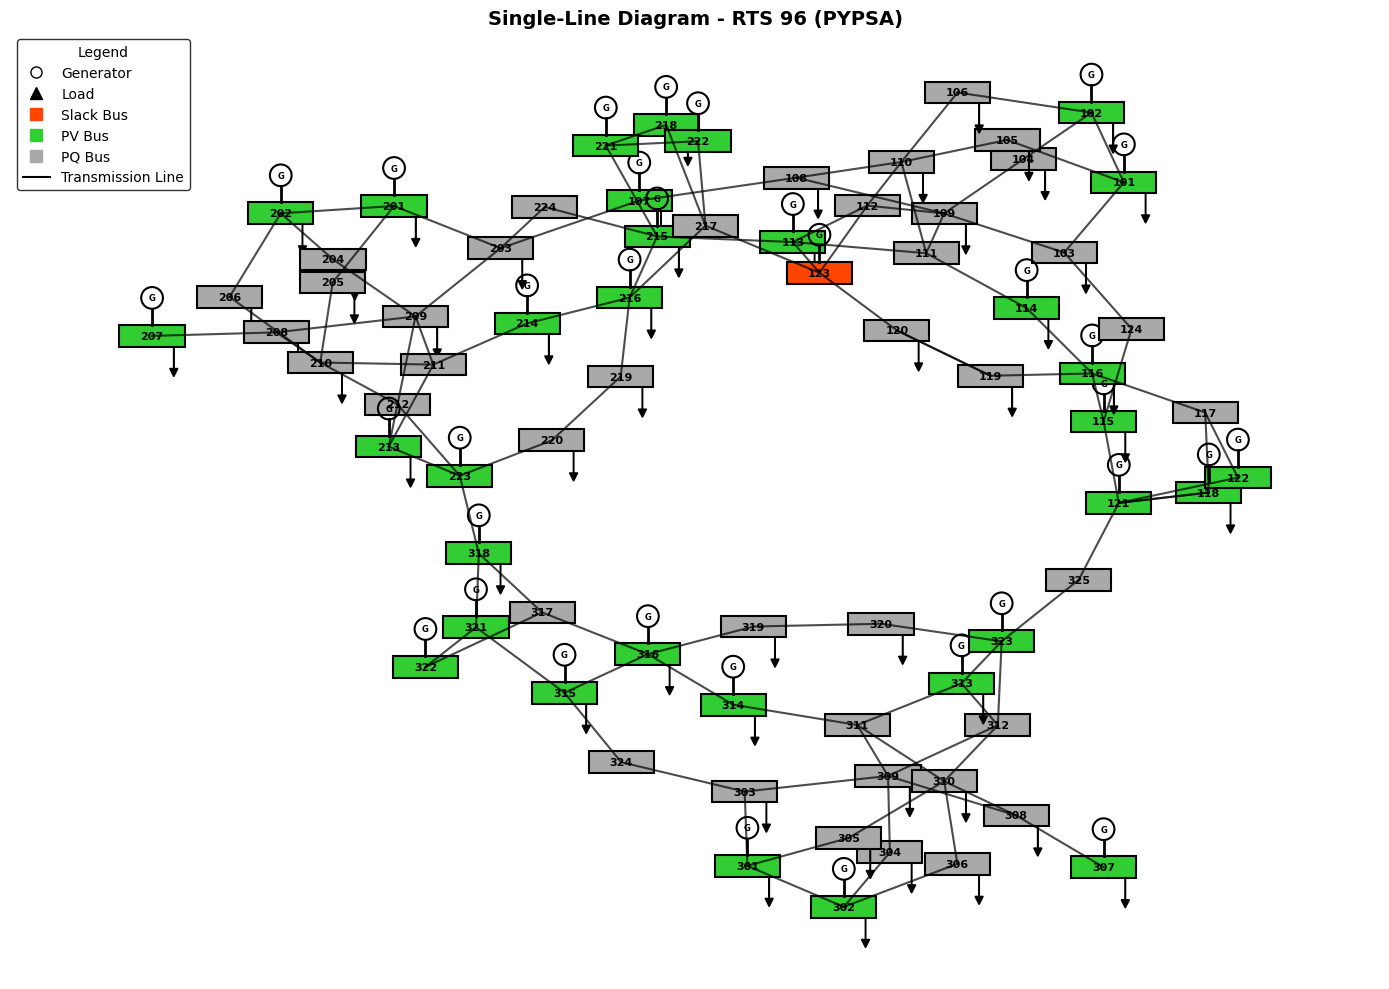

In [2]:
example4.plot.sld()

---

## Apply the WEC-Farms

Lets create 3 WEC Farm. These Farms will have 10 RM3 devices each.

In [3]:
###### RM3 Farm Connected to bus 123 
example4.apply_wec(
   farm_name = "RM3-FARM",
   size = 10, 
   wec_sim_id = 1,
   bus_location=326, # create a new bus for farm  
   connecting_bus = 123, 
)

Error adding bus 326. PSS®E error code: 2


AttributeError: 'DataFrame' object has no attribute 'bus'

---

## Run Time Series Simulation with load curve

In [ ]:
example4.simulate()
example4.pypsa.report

PyPSA Simulating: 100%|██████████| 288/288 [02:25<00:00,  1.98step/s]


SolveReport:
├─ Converged: Successful
├─ Simulation Time: 145.23 s
├─ Num Steps: 288
├─ Case: RTS 96
└─ Modeler: pypsa

<AxesSubplot:xlabel='time', ylabel='seconds'>

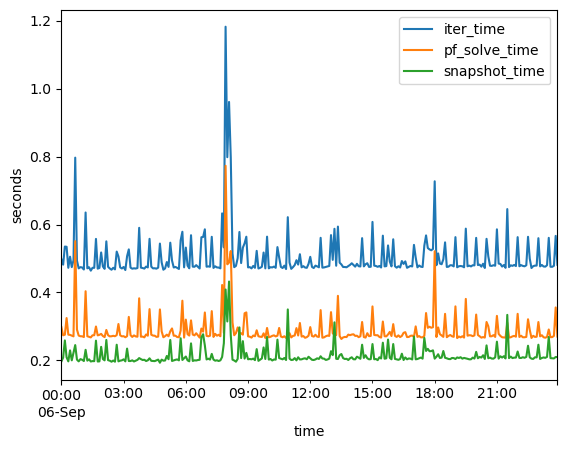

In [ ]:
report = example4.pypsa.report.dataframe
report.plot('snapshot', ['iter_time', 'pf_solve_time', 'snapshot_time'], xlabel='time', ylabel='seconds')

---

## Pre-compiled PSSE simulation

we can pull the pre-compiled PSSE simulation to be able to compare with PyPSA if you don't have PSS/E available.

In [ ]:
example4.database.grid_sims()

,grid_sim_id,sim_name,case_name,psse,pypsa,sbase_mva,sim_start_time,sim_end_time,delta_time,notes,created_at
0,1,PSSE-RTS-GMLC: RM3 Farm,RTS GMLC Hooman,1,0,100.0,2025-08-24T00:00:00,2025-08-24T23:55:00,300,RTS-GMLC grid simulation using PSS/E. The simu...,2025-08-24 20:19:19
1,2,PSSE-RTS-GMLC,RTS GMLC Hooman,1,0,100.0,2025-08-24T00:00:00,2025-08-24T23:55:00,300,RTS-GMLC grid simulation using PSS/E. The simu...,2025-08-24 19:10:55


In [ ]:
psse_grid = example4.database.pull_sim(grid_sim_id=1, software='psse')

GridState reconstructed: RTS GMLC Hooman (PSSE) - 74 buses, 99 generators


---

## Review Grid data

PyPSA

In [ ]:
example4.pypsa.grid

GridState:
├─ Components:
│   ├─ bus:   74 components
│   ├─ gen:   34 components
│   ├─ line:  111 components
│   └─ load:  51 components
├─ Case: RTS 96
└─ Modeler: pypsa

In [ ]:
example4.pypsa.bus_t.p.head()

,Bus_101,Bus_102,Bus_103,Bus_104,Bus_105,Bus_106,Bus_107,Bus_108,Bus_109,Bus_110,...,Bus_317,Bus_318,Bus_319,Bus_320,Bus_321,Bus_322,Bus_323,Bus_324,Bus_325,Bus_326
2025-09-06 00:00:00,0.64,0.75,-1.8,-0.74,-0.71,-1.36,1.15,-1.71,-1.75,-1.95,...,0.0,0.67,-1.81,-1.28,4.0,3.0,5.2,0.0,0.0,0.001353
2025-09-06 00:05:00,0.64,0.75,-1.8,-0.74,-0.71,-1.36,1.15,-1.71,-1.75,-1.95,...,0.0,0.67,-1.81,-1.28,4.0,3.0,5.2,0.0,0.0,0.001353
2025-09-06 00:10:00,0.64,0.75,-1.8,-0.74,-0.71,-1.36,1.15,-1.71,-1.75,-1.95,...,0.0,0.67,-1.81,-1.28,4.0,3.0,5.2,0.0,0.0,0.001971
2025-09-06 00:15:00,0.64,0.75,-1.8,-0.74,-0.71,-1.36,1.15,-1.71,-1.75,-1.95,...,0.0,0.67,-1.81,-1.28,4.0,3.0,5.2,0.0,0.0,0.001916
2025-09-06 00:20:00,0.64,0.75,-1.8,-0.74,-0.71,-1.36,1.15,-1.71,-1.75,-1.95,...,0.0,0.67,-1.81,-1.28,4.0,3.0,5.2,0.0,0.0,0.001507


PSS/E

In [ ]:
psse_grid

GridState:
├─ Components:
│   ├─ bus:   74 components
│   ├─ gen:   99 components
│   ├─ line:  106 components
│   └─ load:  51 components
├─ Case: RTS GMLC Hooman
└─ Modeler: psse

In [ ]:
psse_grid.bus_t.p.head()

,Bus_101,Bus_102,Bus_103,Bus_104,Bus_105,Bus_106,Bus_107,Bus_108,Bus_109,Bus_110,...,Bus_317,Bus_318,Bus_319,Bus_320,Bus_321,Bus_322,Bus_323,Bus_324,Bus_325,Bus_326
2025-08-24 00:00:00,0.6,0.71,-1.8,-0.74,-0.71,-1.36,2.3,-1.71,-1.75,-1.95,...,0.0,0.22,-1.81,-1.28,3.55,3.1,7.1,0.0,0.0,0.001353
2025-08-24 00:05:00,0.6,0.71,-1.8,-0.74,-0.71,-1.36,2.3,-1.71,-1.75,-1.95,...,0.0,0.22,-1.81,-1.28,3.55,3.1,7.1,0.0,0.0,0.001353
2025-08-24 00:10:00,0.6,0.71,-1.8,-0.74,-0.71,-1.36,2.3,-1.71,-1.75,-1.95,...,0.0,0.22,-1.81,-1.28,3.55,3.1,7.1,0.0,0.0,0.001971
2025-08-24 00:15:00,0.6,0.71,-1.8,-0.74,-0.71,-1.36,2.3,-1.71,-1.75,-1.95,...,0.0,0.22,-1.81,-1.28,3.55,3.1,7.1,0.0,0.0,0.001916
2025-08-24 00:20:00,0.6,0.71,-1.8,-0.74,-0.71,-1.36,2.3,-1.71,-1.75,-1.95,...,0.0,0.22,-1.81,-1.28,3.55,3.1,7.1,0.0,0.0,0.001507


## Analyze, visualize and compare results

In [ ]:
# add our 'external' grid to WEC-Grid 
example4.plot.add_grid(software='psse', grid_state=psse_grid)

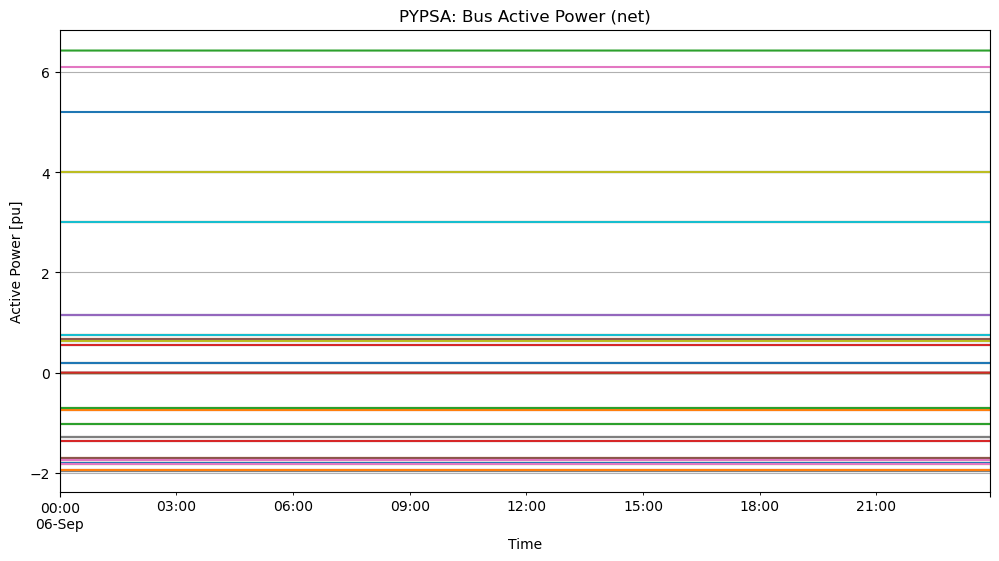

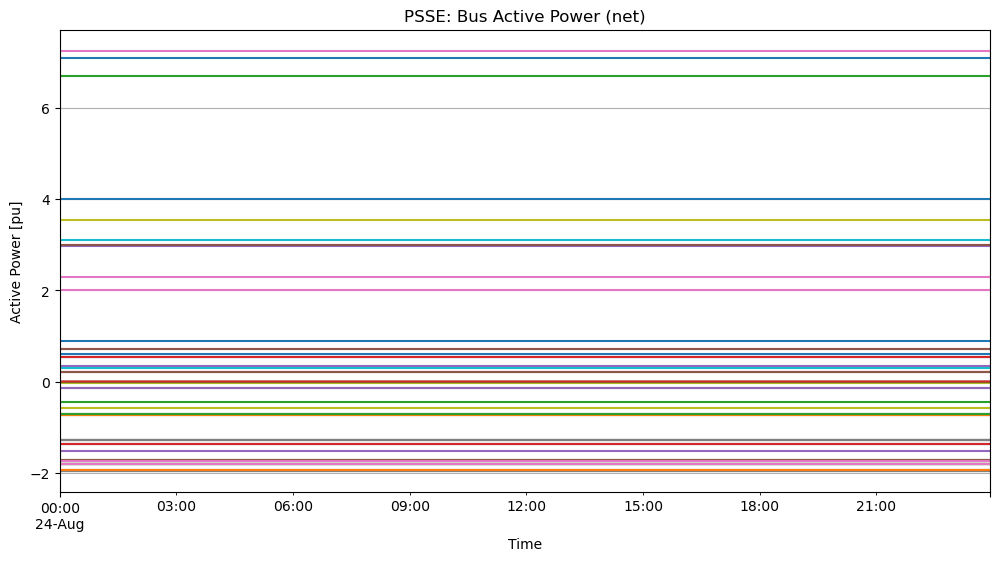

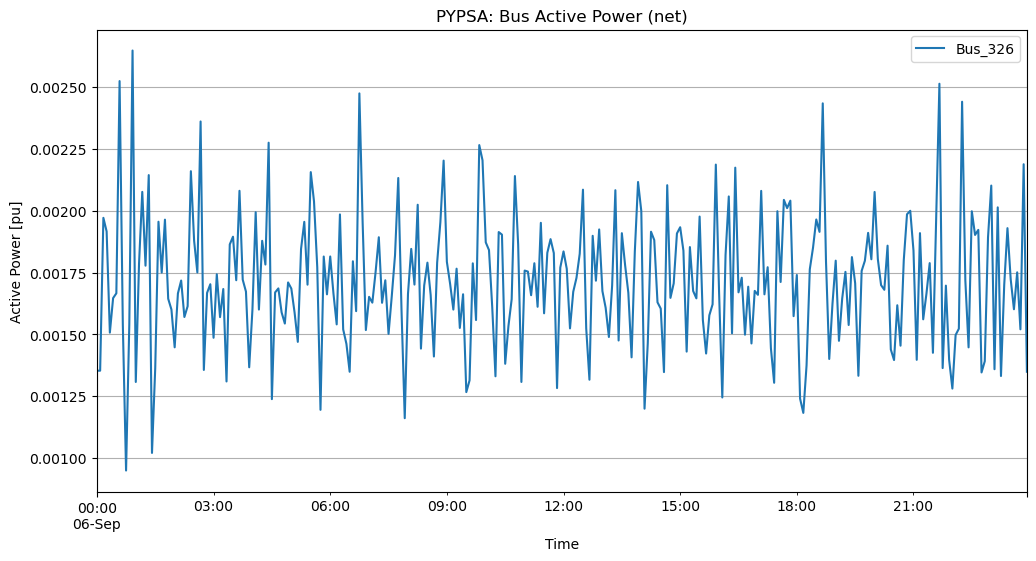

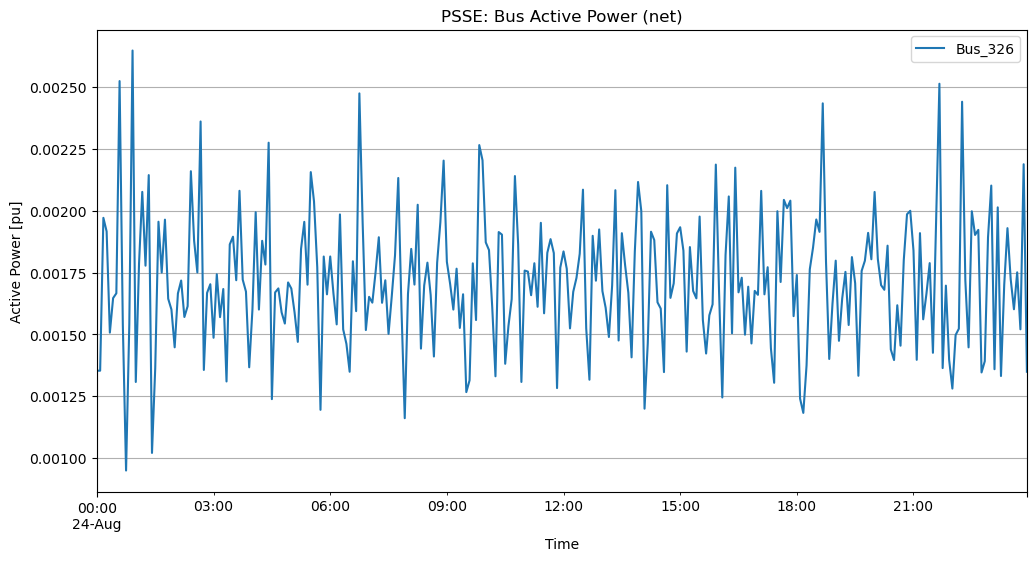

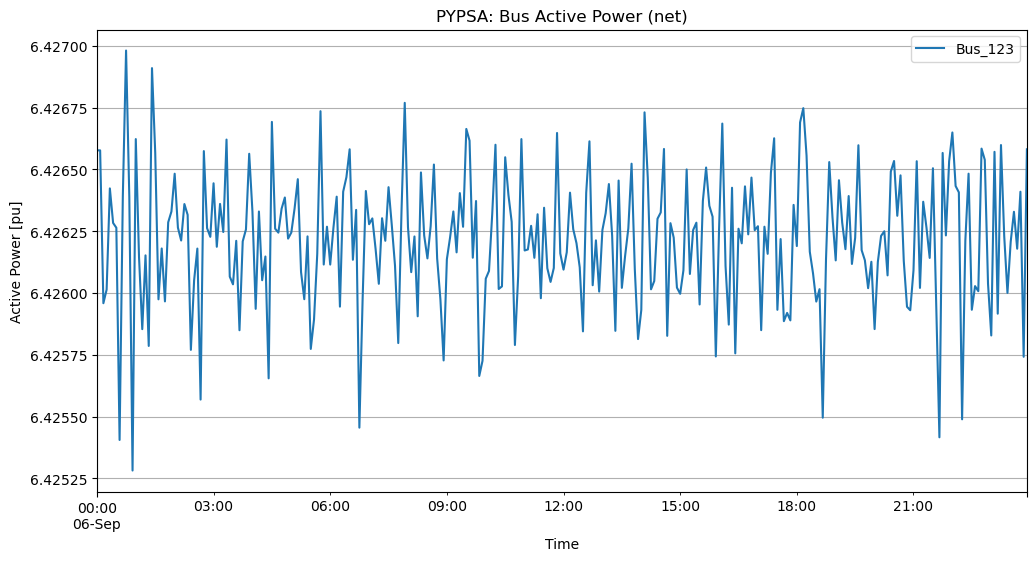

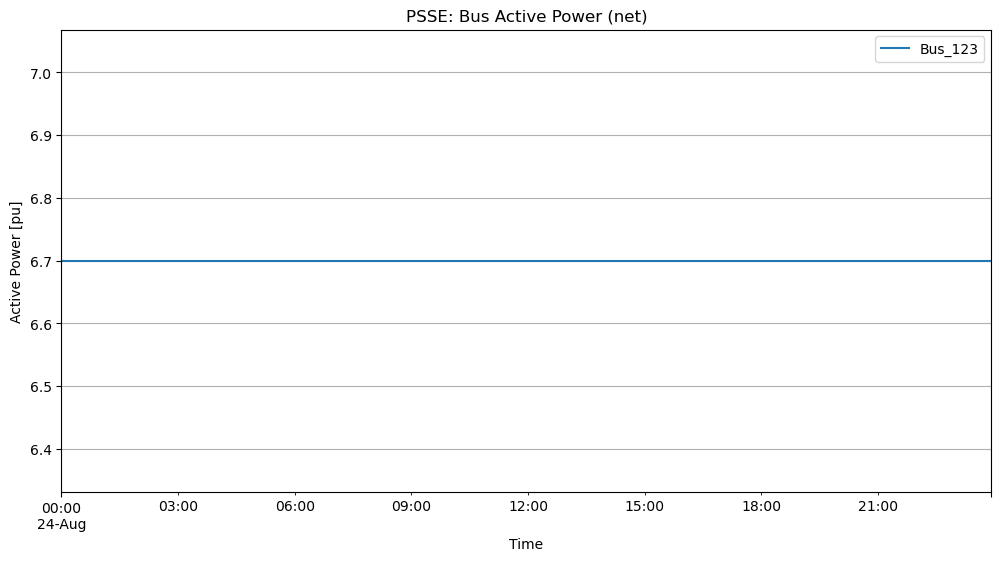

(<Figure size 1200x600 with 1 Axes>,
 <AxesSubplot:title={'center':'PSSE: Bus Active Power (net)'}, xlabel='Time', ylabel='Active Power [pu]'>)

In [ ]:
example4.plot.bus("pypsa",)
example4.plot.bus("psse")
example4.plot.bus(software="pypsa", bus=['Bus_326'])
example4.plot.bus(software="psse", bus=['Bus_326'])
example4.plot.bus(software="pypsa", bus=['Bus_123'])
example4.plot.bus(software="psse", bus=['Bus_123'])

## Compare

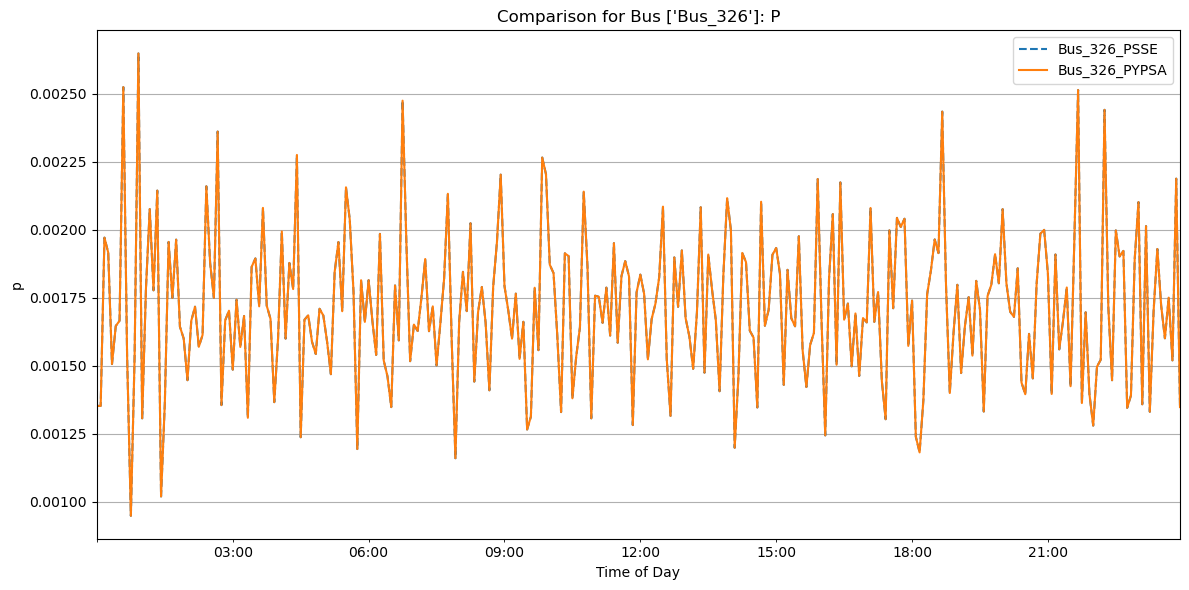

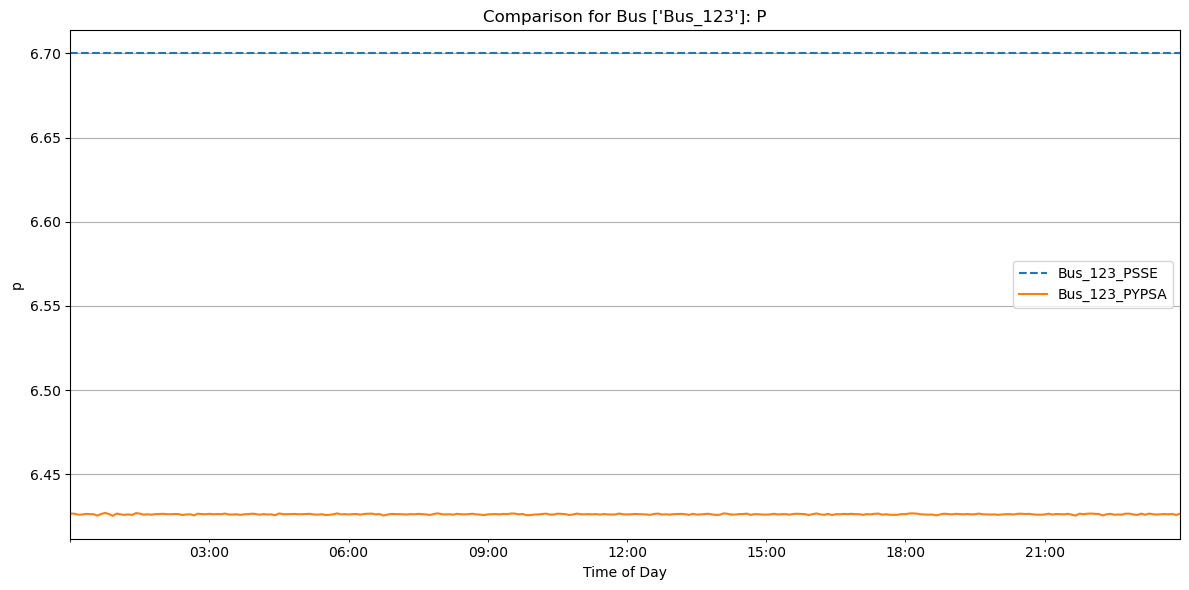

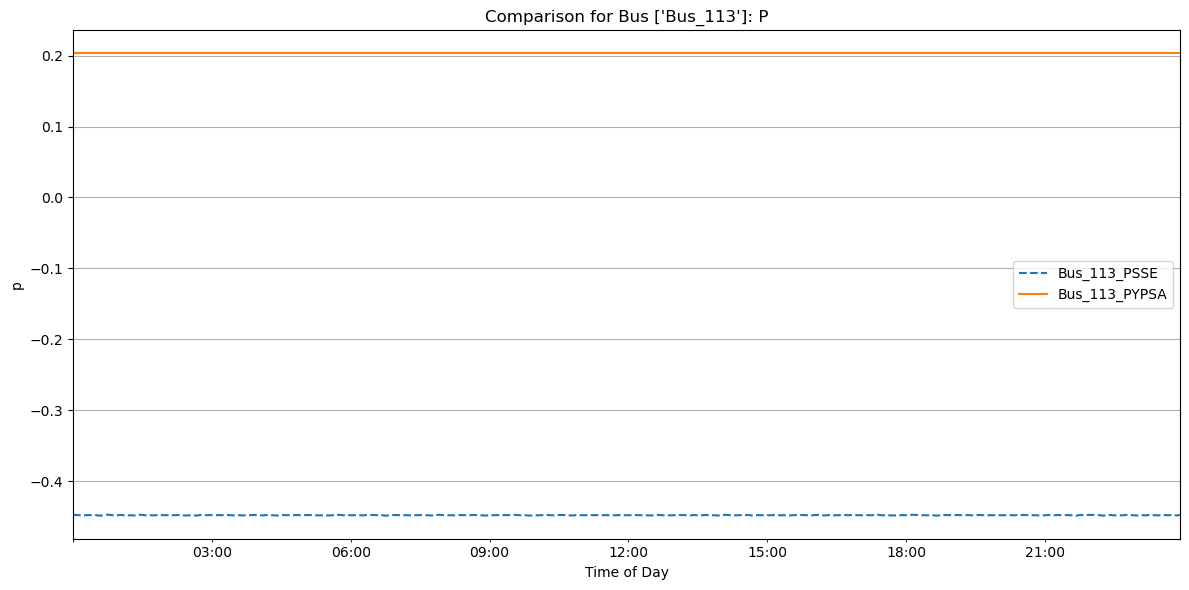

In [ ]:
example4.plot.compare_modelers(grid_component='bus', name=['Bus_326'], parameter='p')
example4.plot.compare_modelers(grid_component='bus', name=['Bus_123'], parameter='p')
example4.plot.compare_modelers(grid_component='bus', name=['Bus_113'], parameter='p')

## Comparison Metrics